In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals


sys.path.append("/uscms/home/reshmar/nobackup/IDMe_Run3_Collab/CMSSW_13_0_13/src/iDMe/python_analysis/analysisTools")
import plotTools as ptools
import utils

In [2]:
f_sig = "/uscms/home/reshmar/nobackup/IDMe_Run3_Collab/CMSSW_13_0_13/src/iDMe/python_analysis/coffea/AllInOne_2022/dxy_res_histo_inpTbins.coffea"
# f_sig = "/uscms/home/reshmar/nobackup/IDMe_Run3_Collab/CMSSW_13_0_13/src/iDMe/python_analysis/coffea/BigSamples_2022/Futures_Resolution.coffea"

sig_histo = util.load(f_sig) [0]
# sig_histo

sig_2022_Mchi-11p0_dMchi-2p0_ctau-100
Hist(
  Variable([0, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 22, 30], name='Gen_dxy_res'),
  Regular(800, -0.8, 0.8, name='Res_GED'),
  storage=Weight()) # Sum: WeightedSum(value=932, variance=932) (WeightedSum(value=2506, variance=2506) with flow)
sig_2022_Mchi-22p0_dMchi-4p0_ctau-100
sig_2022_Mchi-33p0_dMchi-6p0_ctau-100
sig_2022_Mchi-44p0_dMchi-8p0_ctau-100
sig_2022_Mchi-55p0_dMchi-10p0_ctau-100
sig_2022_Mchi-63p0_dMchi-6p0_ctau-100
sig_2022_Mchi-66p0_dMchi-12p0_ctau-100
sig_2022_Mchi-73p5_dMchi-7p0_ctau-100
sig_2022_Mchi-77p0_dMchi-14p0_ctau-100
sig_2022_Mchi-84p0_dMchi-8p0_ctau-100
sig_2022_Mchi-88p0_dMchi-16p0_ctau-100
sig_2022_Mchi-94p5_dMchi-9p0_ctau-100
sig_2022_Mchi-99p0_dMchi-18p0_ctau-100
sig_2022_Mchi-105p0_dMchi-10p0_ctau-100
sig_2022_Mchi-110p0_dMchi-20p0_ctau-100


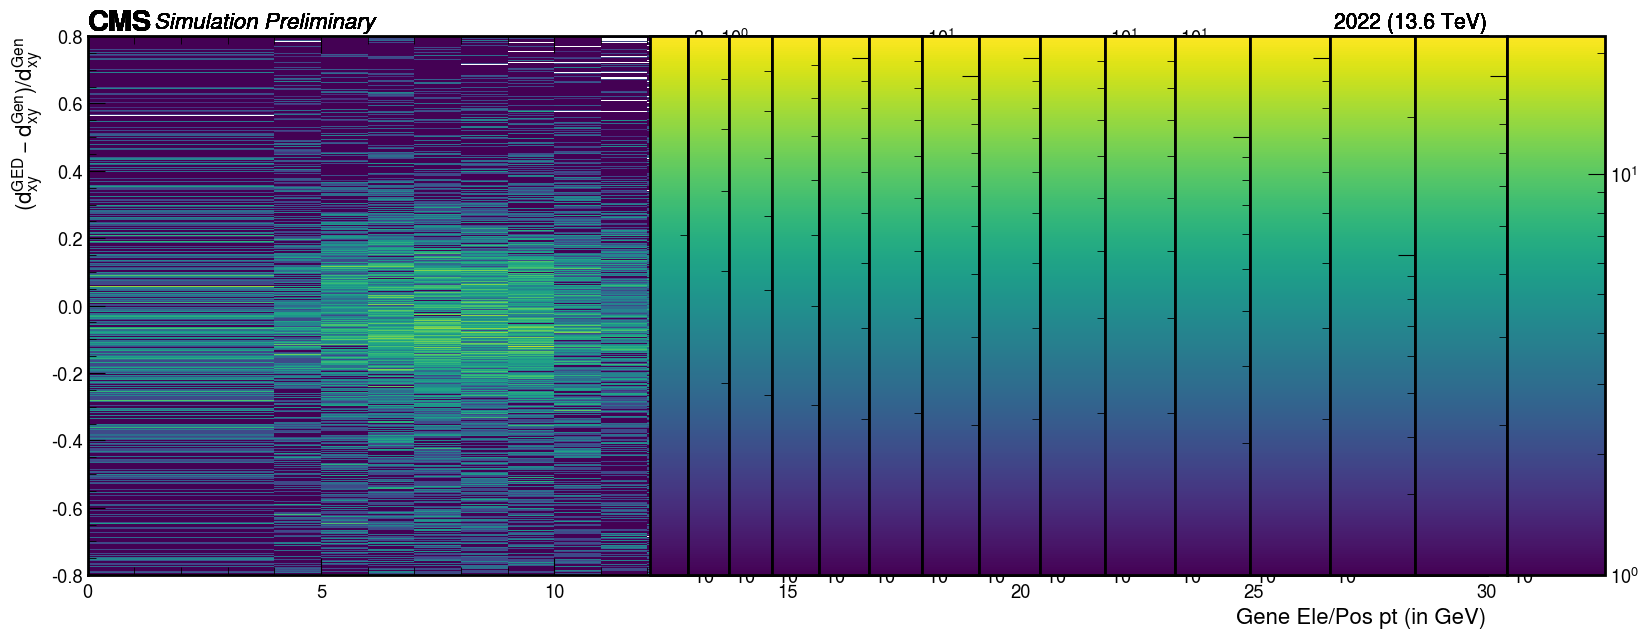

In [3]:
fig, ax = plt.subplots(figsize=(7,7))


# Plot settings
plot_dict = {
    'variable':'res_GED_gen_ptbin',
    'cut': 'cut1',
    'year': 2022
}


style_2d_dict = {
    'fig': fig,
    'ax': ax,
    'xrebin': None,
    'yrebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]  
    'ylim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doLogz': True,
    'xlabel': "Gene Ele/Pos pt (in GeV)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': r'$(d_{xy}^{\mathrm{GED}}-d_{xy}^{\mathrm{Gen}})/d_{xy}^{\mathrm{Gen}}$',   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'zlabel': None,   
    'flow': None,     # overflow
    'doSave': False,
    'outDir': './plots/signal_2018',
    'outName': f'ptvslxy.png'
}


samples = {
    10: 
    {
        
        0.2: [100],
    },
    20: 
    {
        
        0.2: [100],
        
    },
    30: 
    {
       
        0.2: [100]
    },
    40: 
    {
        0.2: [100],
    },
    50:
    {
        
        0.2: [100],
    },
    60:
    {
        
         0.1: [100],
         0.2: [100]
    
    },
    70:
    {    0.1: [100],
         0.2: [100],
    },
    80:
    {    0.1: [100],
         0.2: [100],
    },
    90:
    {    0.1: [100],
         0.2: [100],
    },
    100:
    {    0.1: [100],
         0.2: [100],
    }
 
}

h_list_lpt=[]
h_sum_lpt = None

for m1,deltas in samples.items():
    for delta, ctaus in deltas.items():
        for ctau in ctaus:
            h_lpt = ptools.plot_signal_2D(sig_histo, m1, delta, ctau, plot_dict, style_2d_dict)
            h_list_lpt.append(h_lpt)            
            if h_sum_lpt is None:
                h_sum_lpt = h_lpt.copy()
                print (h_sum_lpt)
            else:
                h_sum_lpt += h_lpt



# Per-pT-bin DSCB fit tuning

This notebook keeps the **same dxy relative-residual histogram**

\[
(d_{xy}^{GED}-d_{xy}^{Gen})/d_{xy}^{Gen}
\]

and the same stored/rebinned histogram. Only the DSCB fitting procedure is improved.

The main changes are robust core starting values, more sensible Crystal-Ball tail seeds, and a multi-start fit. Each fit range is tried from several starting points and the converged solution with the smallest chi2 is retained. Fit-range scanning is then performed independently in every generated-pT bin.


In [4]:
# ============================================================
# SETTINGS: keep the original histogram quantity and binning;
# improve the DSCB fit only
# ============================================================

# SAME residual-bin width as before.
RES_BIN_WIDTH = 0.012

# SAME baseline range as your current notebook.
ORIGINAL_FIT_RANGE = (-0.70, 0.70)

# Display range only. This does NOT affect curve_fit.
plot_min = -0.50
plot_max =  0.50

# Protect the fitted core width while scanning fit ranges.
MAX_SIGMA_REL_CHANGE = 0.15

N_PARAMETERS = 7
MIN_NDOF = 8

# Same idea as before: let each generated-pT bin choose its fit range independently.
FIT_RANGE_CANDIDATES = [
    (-0.70,  0.70),
    (-0.50,  0.50),
    (-0.40,  0.40),
    (-0.30,  0.30),
    (-0.30,  0.25),
    (-0.25,  0.30),
    (-0.25,  0.25),
    (-0.25,  0.20),
    (-0.20,  0.25),
    (-0.20,  0.20),
    (-0.20,  0.15),
    (-0.15,  0.20),
    (-0.15,  0.15),
]

MANUAL_RANGE_OVERRIDE = {}

print(f'Baseline fit range       : {ORIGINAL_FIT_RANGE}')
print(f'Residual bin width       : {RES_BIN_WIDTH}')
print(f'Max allowed sigma change: {MAX_SIGMA_REL_CHANGE:.0%}')
print(f'Number of range choices  : {len(FIT_RANGE_CANDIDATES)}')


Baseline fit range       : (-0.7, 0.7)
Residual bin width       : 0.012
Max allowed sigma change: 15%
Number of range choices  : 13


In [5]:
# ============================================================
# Build the histogram used for all fits -- identical bin width for every pT bin
# ============================================================

original_edges = h_sum_lpt.axes[1].edges

original_widths = np.diff(original_edges)

if not np.allclose(original_widths, original_widths[0]):
    raise ValueError(
        'The stored residual axis has variable-width bins. '
        'This notebook assumes uniform stored bins.'
    )

stored_width = original_widths[0]
rebin_factor = int(round(RES_BIN_WIDTH / stored_width))

if rebin_factor < 1:
    raise ValueError(
        f'Requested residual width {RES_BIN_WIDTH:g} is finer than stored width {stored_width:g}.'
    )

actual_width = rebin_factor * stored_width
if not np.isclose(actual_width, RES_BIN_WIDTH):
    raise ValueError(
        f'Requested width {RES_BIN_WIDTH:g} is not an integer multiple of stored width {stored_width:g}.'
    )

h_fit = h_sum_lpt[:, hist.rebin(rebin_factor)]

print(f'Stored residual bin width : {stored_width:g}')
print(f'Rebin factor              : {rebin_factor}')
print(f'Residual bin width used   : {actual_width:g}')
print(f'Generated-pT bins         : {list(h_fit.axes[0].edges)}')

Stored residual bin width : 0.002
Rebin factor              : 6
Residual bin width used   : 0.012
Generated-pT bins         : [0.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 22.0, 30.0]


In [6]:
# ============================================================
# DSCB MODEL -- unchanged from the original pT notebook
# ============================================================

def double_cb(x, u, sig, nl, a_l, nr, a_r, N):
    t = (x-u)/sig
    al = abs(a_l)
    ar = abs(a_r)

    left_tail = t < -al
    core = (t >= -al) & (t <= ar)
    right_tail = t > ar

    y = np.empty_like(t)
    y[core] = np.exp(-0.5*t[core]*t[core])

    A_L = (nl/al)**nl * np.exp(-0.5*al**2)
    B_L = (nl/al) - al
    y[left_tail] = A_L / (B_L - t[left_tail])**nl

    A_R = (nr/ar)**nr * np.exp(-0.5*ar**2)
    B_R = (nr/ar) - ar
    y[right_tail] = A_R / (B_R + t[right_tail])**nr

    return N*y

In [7]:
# ============================================================
# Extract one pT bin + robust MULTI-START DSCB fit
# ============================================================
from scipy.optimize import curve_fit


def make_bin_data(ptbin_index):
    """Return histogram values and uncertainties for one generated-pT bin."""
    pt_low = h_fit.axes[0].edges[ptbin_index]
    pt_high = h_fit.axes[0].edges[ptbin_index + 1]

    y = h_fit[ptbin_index, :].values()
    variances = h_fit[ptbin_index, :].variances()
    yerr = np.sqrt(variances)
    edges = h_fit.axes[1].edges
    x = 0.5 * (edges[:-1] + edges[1:])

    return {
        'ptbin_index': ptbin_index,
        'genpt_bin': (pt_low, pt_high),
        'xdata': x,
        'ydata': y,
        'yerror': yerr,
    }


def weighted_quantile(x, w, q):
    """Weighted quantile used only to construct robust starting values."""
    order = np.argsort(x)
    xs = np.asarray(x)[order]
    ws = np.asarray(w)[order]
    cdf = np.cumsum(ws)

    if cdf[-1] <= 0:
        raise ValueError("Cannot calculate weighted quantile with zero total weight.")

    return np.interp(q * cdf[-1], cdf, xs)


def fit_one_bin(ptbin_index, fit_range):
    """
    Fit one generated-pT bin with the SAME DSCB model and SAME residual quantity.

    Improvements relative to the previous notebook:
      1. robust mu/sigma starting values from the central weighted distribution;
      2. physically sensible Crystal-Ball tail starting values;
      3. several starting points are tried;
      4. the converged solution with the smallest chi2 is retained.

    No histogram quantity is changed.
    """
    data = make_bin_data(ptbin_index)
    x = data['xdata']
    y = data['ydata']
    sig_y = data['yerror']

    fit_min_i, fit_max_i = fit_range

    mask = (
        (y > 0) &
        (sig_y > 0) &
        np.isfinite(y) &
        np.isfinite(sig_y) &
        (x >= fit_min_i) &
        (x <= fit_max_i)
    )

    xfit = x[mask]
    yfit = y[mask]
    yerrfit = sig_y[mask]

    ndof = len(xfit) - N_PARAMETERS
    if ndof < MIN_NDOF:
        raise ValueError(
            f'pT bin {ptbin_index}: only {len(xfit)} populated fit points '
            f'in range {fit_range}, giving ndof={ndof}.'
        )

    # --------------------------------------------------------
    # Robust core estimates for STARTING VALUES ONLY.
    # This does not redefine the resolution quantity.
    # --------------------------------------------------------
    q16 = weighted_quantile(xfit, yfit, 0.16)
    q50 = weighted_quantile(xfit, yfit, 0.50)
    q84 = weighted_quantile(xfit, yfit, 0.84)

    mu0 = q50
    sigma0 = 0.5 * (q84 - q16)

    # Fall back to weighted RMS only if the central-68% estimate is pathological.
    if (not np.isfinite(sigma0)) or sigma0 <= 0:
        mu0 = np.average(xfit, weights=yfit)
        sigma0 = np.sqrt(np.average((xfit - mu0)**2, weights=yfit))

    bin_width = np.median(np.diff(xfit))
    sigma0 = max(sigma0, bin_width)

    # --------------------------------------------------------
    # Better bounds:
    # alpha around O(1) means the Gaussian core is actually allowed
    # to exist before the power-law tails start.
    # --------------------------------------------------------
    lower = [
        xfit.min(),          # mu
        max(0.25*bin_width, 1e-5),  # sigma
        1.01,               # nL
        0.50,               # alphaL
        1.01,               # nR
        0.50,               # alphaR
        0.0                  # normalization
    ]

    upper = [
        xfit.max(),
        xfit.max() - xfit.min(),
        20.0,
        5.0,
        20.0,
        5.0,
        10.0*yfit.max()
    ]

    # --------------------------------------------------------
    # Multi-start: DSCB has correlated tail parameters and can
    # converge to different local minima from one initial guess.
    # --------------------------------------------------------
    tail_starts = [
        (2.0, 1.0, 2.0, 1.0),
        (3.0, 1.5, 3.0, 1.5),
        (5.0, 2.0, 5.0, 2.0),
        (2.0, 1.5, 5.0, 2.0),
        (5.0, 2.0, 2.0, 1.5),
    ]

    sigma_scales = [0.75, 1.0, 1.25]

    best = None
    failures = []

    for sigma_scale in sigma_scales:
        for nl0, al0, nr0, ar0 in tail_starts:
            p0 = [
                np.clip(mu0, lower[0] + 1e-8, upper[0] - 1e-8),
                np.clip(sigma0*sigma_scale, lower[1]*1.01, upper[1]*0.95),
                nl0, al0, nr0, ar0,
                yfit.max()
            ]

            try:
                popt, pcov = curve_fit(
                    double_cb,
                    xfit,
                    yfit,
                    p0=p0,
                    sigma=yerrfit,
                    absolute_sigma=True,
                    bounds=(lower, upper),
                    maxfev=100000,
                )

                prediction = double_cb(xfit, *popt)
                chi2 = np.sum(((yfit - prediction)/yerrfit)**2)

                # Reject obviously unusable covariance matrices.
                perr = np.sqrt(np.diag(pcov))
                if not np.all(np.isfinite(perr)):
                    continue

                candidate = {
                    'popt': popt,
                    'pcov': pcov,
                    'perr': perr,
                    'chi2': chi2,
                }

                if best is None or chi2 < best['chi2']:
                    best = candidate

            except Exception as exc:
                failures.append(str(exc))

    if best is None:
        raise RuntimeError(
            f'pT bin {ptbin_index}, range {fit_range}: all DSCB starts failed. '
            f'First failure: {failures[0] if failures else "unknown"}'
        )

    popt = best['popt']
    pcov = best['pcov']
    perr = best['perr']
    chi2 = best['chi2']
    chi2ndof = chi2 / ndof

    return {
        **data,
        'fit_range': fit_range,
        'xfit': xfit,
        'yfit': yfit,
        'yerrfit': yerrfit,
        'popt': popt,
        'pcov': pcov,
        'perr': perr,
        'chi2': chi2,
        'ndof': ndof,
        'chi2/ndof': chi2ndof,
        'fit_mean': popt[0],
        'fit_mean_unc': perr[0],
        'fit_sigma': popt[1],
        'fit_sigma_unc': perr[1],

        # Useful diagnostics for checking whether a parameter sits on a bound.
        'nL': popt[2],
        'alphaL': popt[3],
        'nR': popt[4],
        'alphaR': popt[5],
        'start_mu': mu0,
        'start_sigma': sigma0,
    }


## 1. Baseline fits

First reproduce the original `[-0.30, 0.30]` fit for every generated-pT bin. These values define the **reference sigma** for that pT bin. Candidate ranges are compared to this sigma, not to one global sigma.

In [8]:
baseline_results = {}
baseline_rows = []

n_pt_bins = len(h_fit.axes[0].edges) - 1

for idx in range(n_pt_bins):
    result = fit_one_bin(idx, ORIGINAL_FIT_RANGE)
    baseline_results[idx] = result

    baseline_rows.append({
        'pT bin index': idx,
        'gen pT range': result['genpt_bin'],
        'fit range': result['fit_range'],
        'sigma': result['fit_sigma'],
        'sigma unc': result['fit_sigma_unc'],
        'chi2/ndof': result['chi2/ndof'],
        'ndof': result['ndof'],
    })

baseline_df = pd.DataFrame(baseline_rows)
display(baseline_df)

,pT bin index,gen pT range,fit range,sigma,sigma unc,chi2/ndof,ndof
0,0,"(0.0, 4.0)","(-0.7, 0.7)",0.200994,0.008116,1.963297,110
1,1,"(4.0, 5.0)","(-0.7, 0.7)",0.209054,0.007535,1.557911,110
2,2,"(5.0, 6.0)","(-0.7, 0.7)",0.210330,0.006585,2.334222,110
3,3,"(6.0, 7.0)","(-0.7, 0.7)",0.198344,0.006806,1.968709,110
4,4,"(7.0, 8.0)","(-0.7, 0.7)",0.200660,0.007849,1.915741,110
5,5,"(8.0, 9.0)","(-0.7, 0.7)",0.218170,0.007037,2.371222,110
6,6,"(9.0, 10.0)","(-0.7, 0.7)",0.236581,0.008133,1.987437,110
7,7,"(10.0, 11.0)","(-0.7, 0.7)",0.226878,0.012784,1.856539,110
8,8,"(11.0, 12.0)","(-0.7, 0.7)",0.218262,0.016226,1.810408,110
9,9,"(12.0, 13.0)","(-0.7, 0.7)",0.239274,0.012932,1.822130,110


## 2. Scan fit ranges independently for every pT bin

For each pT bin, every candidate range is fit independently. A candidate is marked **sigma stable** when

\[
\frac{|\sigma_{\rm candidate}-\sigma_{\rm baseline}|}{\sigma_{\rm baseline}} \leq 10\%.
\]

A candidate must also successfully converge and retain enough degrees of freedom. Among the stable candidates, the notebook chooses the one with the lowest chi2/ndof. The original range is always available, so a bin can remain unchanged.

In [9]:
range_scan_rows = []
range_scan_fits = {idx: {} for idx in range(n_pt_bins)}
selected_fit_ranges = {}
selection_rows = []

for idx in range(n_pt_bins):
    baseline = baseline_results[idx]
    baseline_sigma = baseline['fit_sigma']
    baseline_chi2ndof = baseline['chi2/ndof']

    successful_stable_results = []

    for fit_range in FIT_RANGE_CANDIDATES:
        try:
            result = fit_one_bin(idx, fit_range)
            range_scan_fits[idx][fit_range] = result

            sigma_rel_change = abs(result['fit_sigma'] - baseline_sigma) / baseline_sigma
            sigma_stable = sigma_rel_change <= MAX_SIGMA_REL_CHANGE

            range_scan_rows.append({
                'pT bin index': idx,
                'gen pT range': result['genpt_bin'],
                'fit range': str(fit_range),
                'sigma': result['fit_sigma'],
                'sigma unc': result['fit_sigma_unc'],
                'sigma rel. change': sigma_rel_change,
                'chi2/ndof': result['chi2/ndof'],
                'ndof': result['ndof'],
                'sigma stable': sigma_stable,
                'fit success': True,
            })

            if sigma_stable:
                successful_stable_results.append(result)

        except Exception as exc:
            range_scan_rows.append({
                'pT bin index': idx,
                'gen pT range': baseline['genpt_bin'],
                'fit range': str(fit_range),
                'sigma': np.nan,
                'sigma unc': np.nan,
                'sigma rel. change': np.nan,
                'chi2/ndof': np.nan,
                'ndof': np.nan,
                'sigma stable': False,
                'fit success': False,
                'failure': str(exc),
            })

    # Baseline should always be in the stable set, but fall back explicitly for safety.
    if successful_stable_results:
        best = min(successful_stable_results, key=lambda r: r['chi2/ndof'])
    else:
        best = baseline

    selected_fit_ranges[idx] = best['fit_range']

    selection_rows.append({
        'pT bin index': idx,
        'gen pT range': baseline['genpt_bin'],
        'baseline range': ORIGINAL_FIT_RANGE,
        'selected range': best['fit_range'],
        'baseline sigma': baseline_sigma,
        'selected sigma': best['fit_sigma'],
        'sigma rel. change': abs(best['fit_sigma']-baseline_sigma)/baseline_sigma,
        'baseline chi2/ndof': baseline_chi2ndof,
        'selected chi2/ndof': best['chi2/ndof'],
        'chi2 improvement': baseline_chi2ndof - best['chi2/ndof'],
    })

range_scan_df = pd.DataFrame(range_scan_rows)
selection_df = pd.DataFrame(selection_rows)

print('All candidate fits:')
display(range_scan_df)

print('\nAutomatically selected range for each pT bin:')
display(selection_df)

All candidate fits:


,pT bin index,gen pT range,fit range,sigma,sigma unc,sigma rel. change,chi2/ndof,ndof,sigma stable,fit success
0,0,"(0.0, 4.0)","(-0.7, 0.7)",0.200994,0.008116,0.000000,1.963297,110,True,True
1,0,"(0.0, 4.0)","(-0.5, 0.5)",0.206422,0.007683,0.027005,1.965235,76,True,True
2,0,"(0.0, 4.0)","(-0.4, 0.4)",0.210537,0.007288,0.047479,1.877393,60,True,True
3,0,"(0.0, 4.0)","(-0.3, 0.3)",0.164243,0.014249,0.182845,1.886377,43,False,True
4,0,"(0.0, 4.0)","(-0.3, 0.25)",0.166625,0.014473,0.170993,1.788322,39,False,True
...,...,...,...,...,...,...,...,...,...,...
203,15,"(22.0, 30.0)","(-0.2, 0.25)",0.301313,0.025122,0.140276,3.016829,31,True,True
204,15,"(22.0, 30.0)","(-0.2, 0.2)",0.216416,0.058947,0.181004,2.886112,26,False,True
205,15,"(22.0, 30.0)","(-0.2, 0.15)",0.226270,0.066972,0.143716,3.170727,22,True,True
206,15,"(22.0, 30.0)","(-0.15, 0.2)",0.214715,0.209285,0.187444,2.456154,22,False,True



Automatically selected range for each pT bin:


,pT bin index,gen pT range,baseline range,selected range,baseline sigma,selected sigma,sigma rel. change,baseline chi2/ndof,selected chi2/ndof,chi2 improvement
0,0,"(0.0, 4.0)","(-0.7, 0.7)","(-0.15, 0.2)",0.200994,0.195429,0.027684,1.963297,1.591404,0.371894
1,1,"(4.0, 5.0)","(-0.7, 0.7)","(-0.5, 0.5)",0.209054,0.206203,0.013639,1.557911,1.366772,0.191140
2,2,"(5.0, 6.0)","(-0.7, 0.7)","(-0.5, 0.5)",0.210330,0.217205,0.032685,2.334222,2.111141,0.223081
3,3,"(6.0, 7.0)","(-0.7, 0.7)","(-0.5, 0.5)",0.198344,0.194608,0.018832,1.968709,1.798457,0.170252
4,4,"(7.0, 8.0)","(-0.7, 0.7)","(-0.7, 0.7)",0.200660,0.200660,0.000000,1.915741,1.915741,0.000000
5,5,"(8.0, 9.0)","(-0.7, 0.7)","(-0.5, 0.5)",0.218170,0.210415,0.035547,2.371222,2.351739,0.019483
6,6,"(9.0, 10.0)","(-0.7, 0.7)","(-0.7, 0.7)",0.236581,0.236581,0.000000,1.987437,1.987437,0.000000
7,7,"(10.0, 11.0)","(-0.7, 0.7)","(-0.7, 0.7)",0.226878,0.226878,0.000000,1.856539,1.856539,0.000000
8,8,"(11.0, 12.0)","(-0.7, 0.7)","(-0.7, 0.7)",0.218262,0.218262,0.000000,1.810408,1.810408,0.000000
9,9,"(12.0, 13.0)","(-0.7, 0.7)","(-0.7, 0.7)",0.239274,0.239274,0.000000,1.822130,1.822130,0.000000


## 3. Visual comparison: baseline vs selected fit

These plots are the main sanity check. The histogram is identical in both fits. Only the data points given to `curve_fit` change.

Pay special attention to whether the selected range removes regions that the DSCB clearly cannot describe while leaving the central peak width essentially unchanged.

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


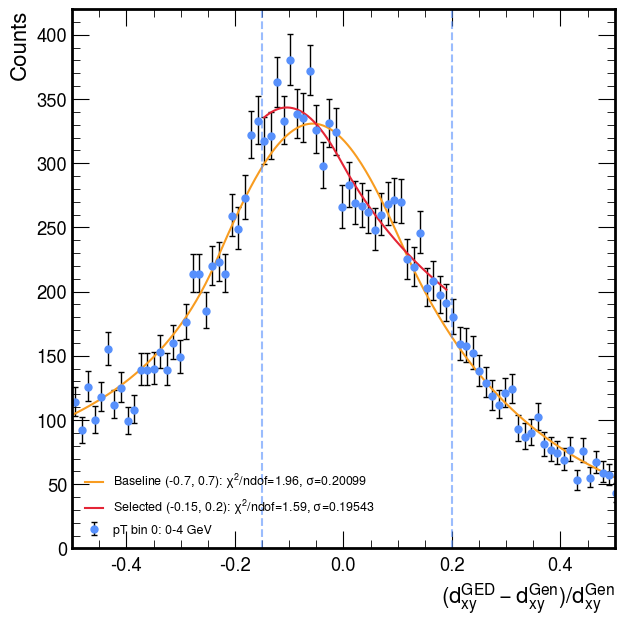

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


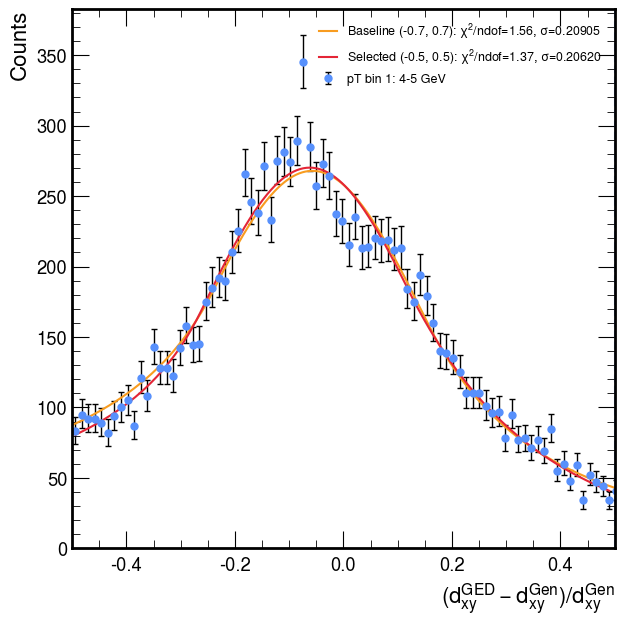

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


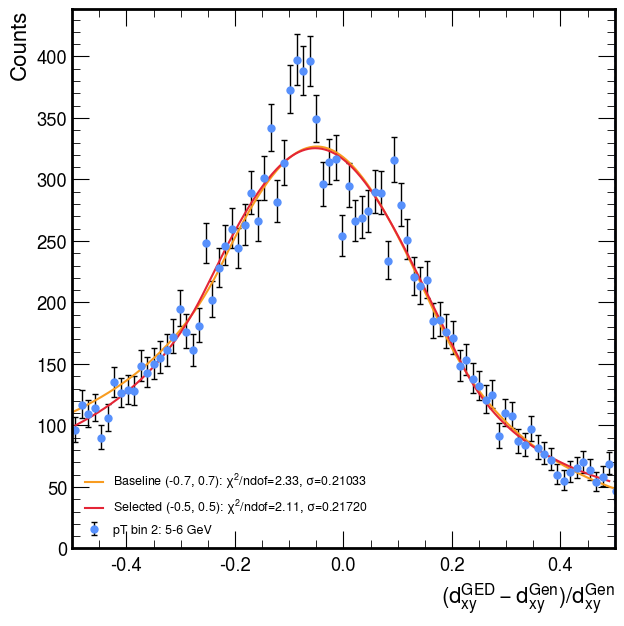

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


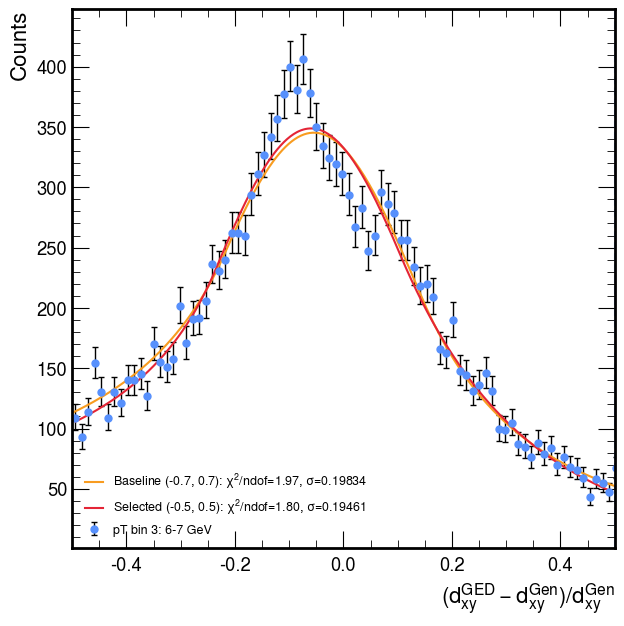

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


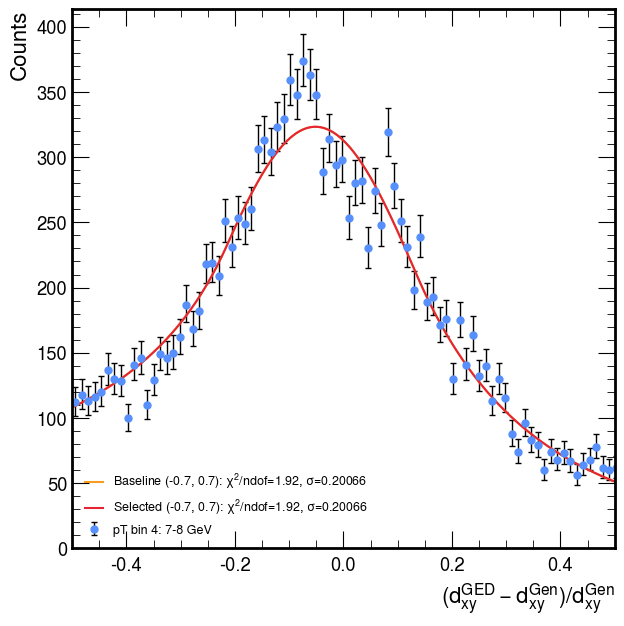

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


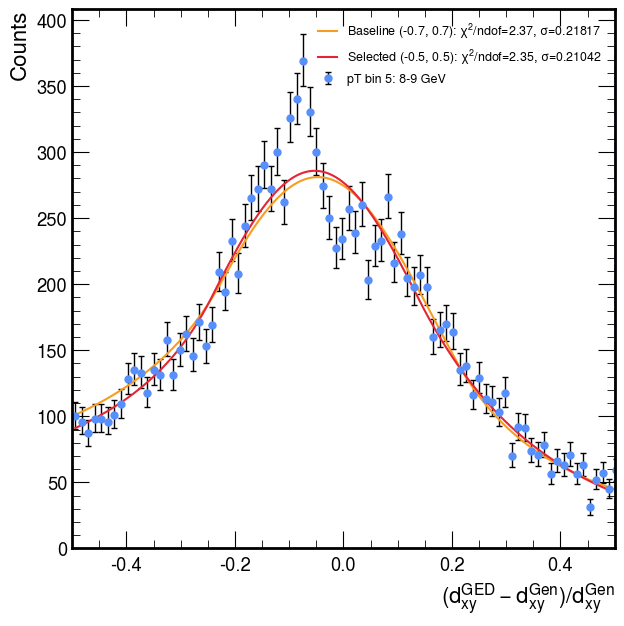

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


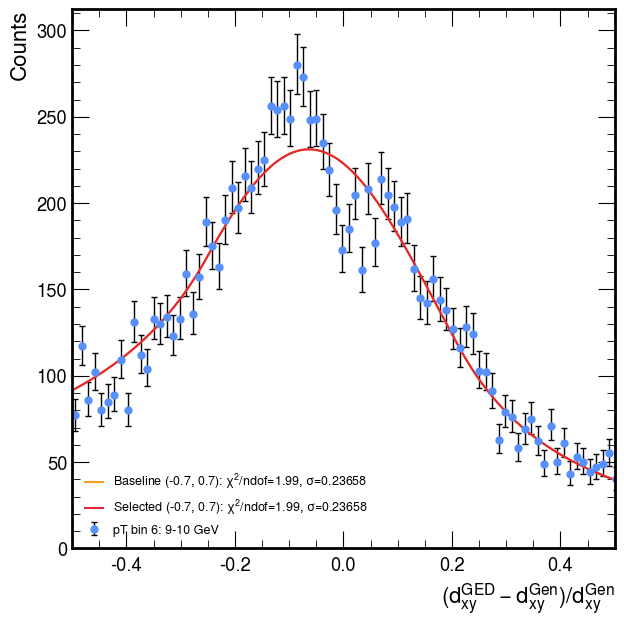

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


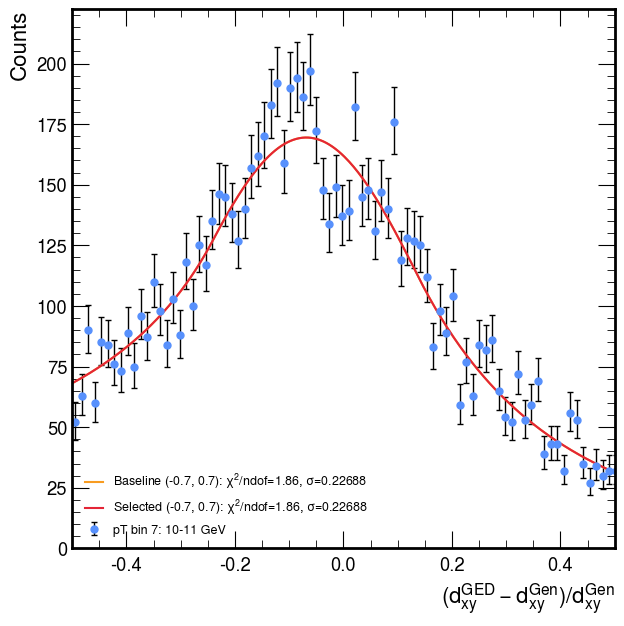

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


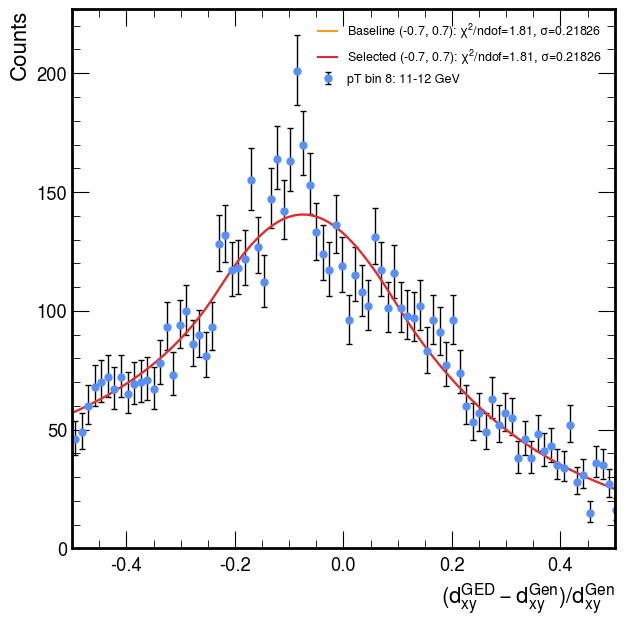

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


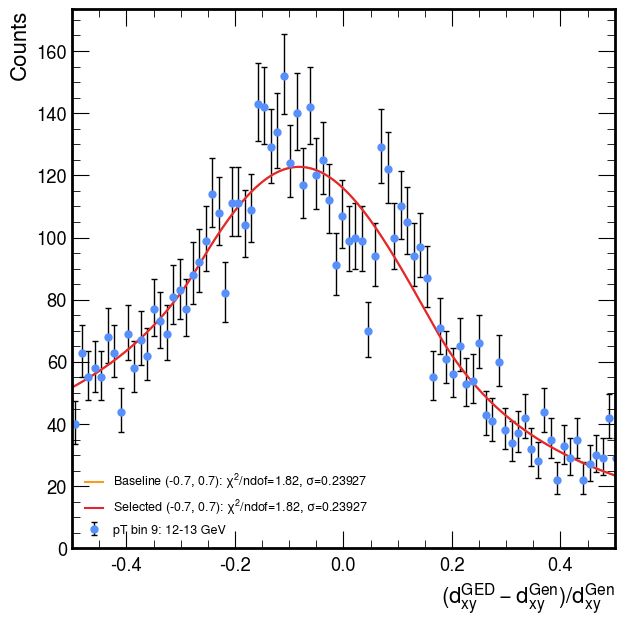

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


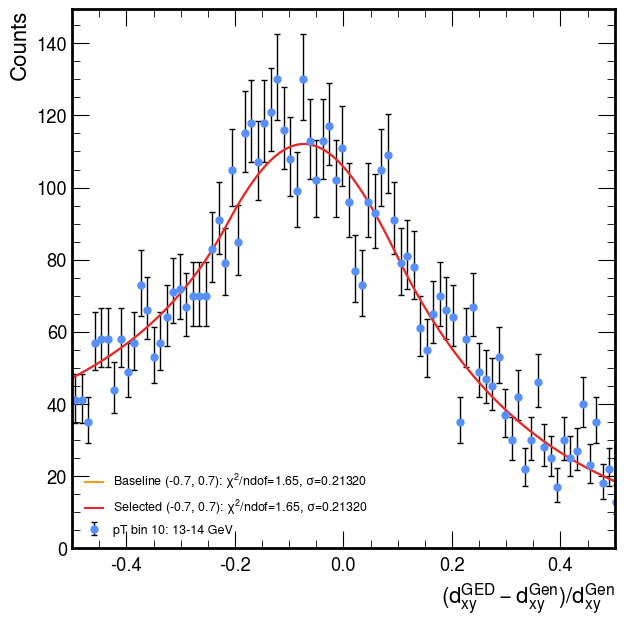

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


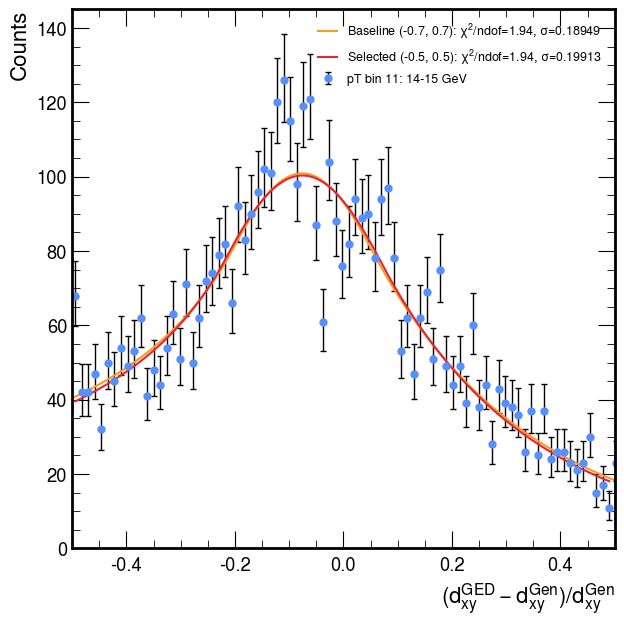

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


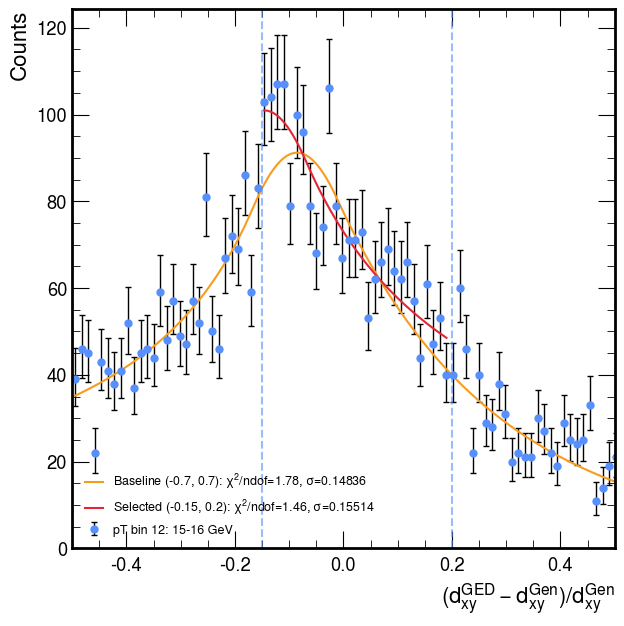

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


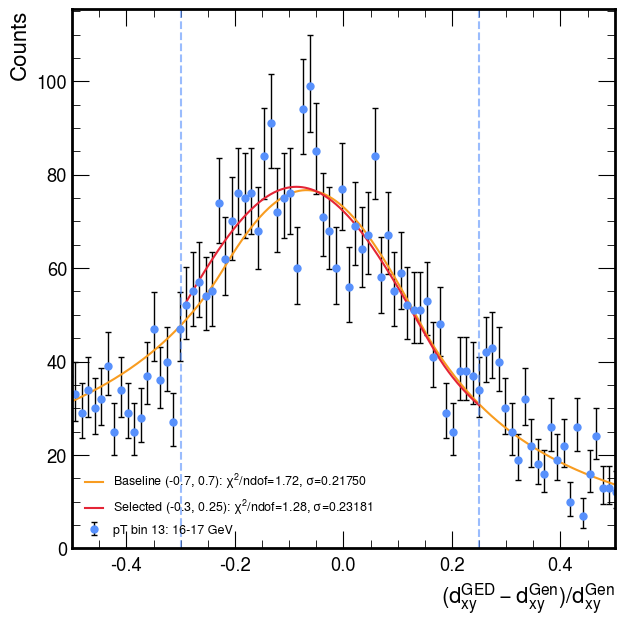

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


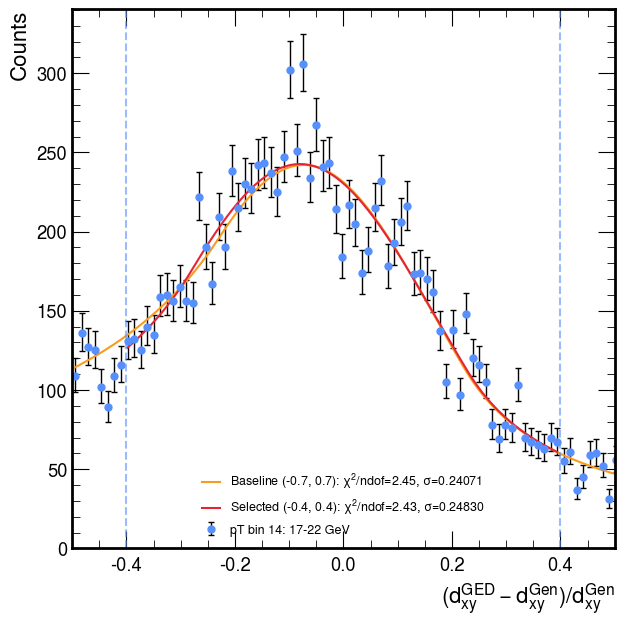

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


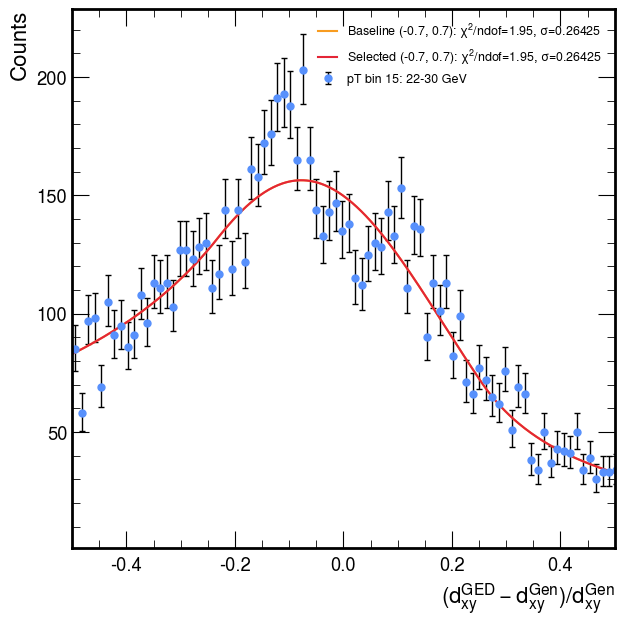

In [10]:
for idx in range(n_pt_bins):
    baseline = baseline_results[idx]
    selected_range = selected_fit_ranges[idx]
    selected = range_scan_fits[idx].get(selected_range, baseline)

    plt.figure(figsize=(7, 7))
    mplhep.histplot(
        h_fit[idx, :],
        histtype='errorbar',
        yerr=True,
        fmt='o',
        capsize=2,
        ecolor='black',
        label=f'pT bin {idx}: {baseline["genpt_bin"][0]:g}-{baseline["genpt_bin"][1]:g} GeV'
    )

    x_base = np.linspace(baseline['xfit'].min(), baseline['xfit'].max(), 500)
    plt.plot(
        x_base,
        double_cb(x_base, *baseline['popt']),
        label=(f'Baseline {ORIGINAL_FIT_RANGE}: '
               f'$\\chi^2$/ndof={baseline["chi2/ndof"]:.2f}, '
               f'$\\sigma$={baseline["fit_sigma"]:.5f}')
    )

    x_sel = np.linspace(selected['xfit'].min(), selected['xfit'].max(), 500)
    plt.plot(
        x_sel,
        double_cb(x_sel, *selected['popt']),
        label=(f'Selected {selected_range}: '
               f'$\\chi^2$/ndof={selected["chi2/ndof"]:.2f}, '
               f'$\\sigma$={selected["fit_sigma"]:.5f}')
    )

    # Visually mark the selected fit interval.
    plt.axvline(selected_range[0], linestyle='--', alpha=0.6)
    plt.axvline(selected_range[1], linestyle='--', alpha=0.6)

    plt.xlim(plot_min, plot_max)
    plt.xlabel(r'$(d_{xy}^{GED}-d_{xy}^{Gen})/d_{xy}^{Gen}$')
    plt.ylabel('Counts')
    plt.legend(fontsize=9)
    plt.show()

## 4. Optional manual overrides

The automatic selection is deliberately conservative, but the overlay plots should still be inspected. If you prefer a specific range for a bin after looking at the physics shape, put it in `MANUAL_RANGE_OVERRIDE` in the settings cell and rerun from there.

The final range dictionary below applies those overrides **without changing any other fit setting**.

In [11]:
final_fit_ranges = selected_fit_ranges.copy()

for idx, fit_range in MANUAL_RANGE_OVERRIDE.items():
    if idx < 0 or idx >= n_pt_bins:
        raise IndexError(f'Manual override pT-bin index {idx} is outside 0..{n_pt_bins-1}.')
    final_fit_ranges[idx] = tuple(fit_range)

print('Final fit ranges:')
for idx in range(n_pt_bins):
    auto_tag = 'manual override' if idx in MANUAL_RANGE_OVERRIDE else 'automatic'
    print(f'  bin {idx:2d}  pT={baseline_results[idx]["genpt_bin"]}  '
          f'range={final_fit_ranges[idx]}  [{auto_tag}]')

Final fit ranges:
  bin  0  pT=(0.0, 4.0)  range=(-0.15, 0.2)  [automatic]
  bin  1  pT=(4.0, 5.0)  range=(-0.5, 0.5)  [automatic]
  bin  2  pT=(5.0, 6.0)  range=(-0.5, 0.5)  [automatic]
  bin  3  pT=(6.0, 7.0)  range=(-0.5, 0.5)  [automatic]
  bin  4  pT=(7.0, 8.0)  range=(-0.7, 0.7)  [automatic]
  bin  5  pT=(8.0, 9.0)  range=(-0.5, 0.5)  [automatic]
  bin  6  pT=(9.0, 10.0)  range=(-0.7, 0.7)  [automatic]
  bin  7  pT=(10.0, 11.0)  range=(-0.7, 0.7)  [automatic]
  bin  8  pT=(11.0, 12.0)  range=(-0.7, 0.7)  [automatic]
  bin  9  pT=(12.0, 13.0)  range=(-0.7, 0.7)  [automatic]
  bin 10  pT=(13.0, 14.0)  range=(-0.7, 0.7)  [automatic]
  bin 11  pT=(14.0, 15.0)  range=(-0.5, 0.5)  [automatic]
  bin 12  pT=(15.0, 16.0)  range=(-0.15, 0.2)  [automatic]
  bin 13  pT=(16.0, 17.0)  range=(-0.3, 0.25)  [automatic]
  bin 14  pT=(17.0, 22.0)  range=(-0.4, 0.4)  [automatic]
  bin 15  pT=(22.0, 30.0)  range=(-0.7, 0.7)  [automatic]


## 5. Final per-bin fits and compact comparison table

This is the fit collection to use downstream. The output retains the same quantities as your original `fit_data`, with the selected range and the baseline comparison added.

In [12]:
fit_data = []
final_fit_results = {}
comparison_rows = []

for idx in range(n_pt_bins):
    final_range = final_fit_ranges[idx]

    # Reuse an already-scanned fit when possible; otherwise evaluate a manual range now.
    if final_range in range_scan_fits[idx]:
        result = range_scan_fits[idx][final_range]
    else:
        result = fit_one_bin(idx, final_range)

    baseline = baseline_results[idx]
    final_fit_results[idx] = result

    sigma_rel_change = abs(result['fit_sigma'] - baseline['fit_sigma']) / baseline['fit_sigma']

    fit_data.append({
        'pT bin index': idx,
        'genptbin_range': result['genpt_bin'],
        'fit_mean': result['fit_mean'],
        'fit_mean_unc': result['fit_mean_unc'],
        'fit_sigma': result['fit_sigma'],
        'fit_sigma_unc': result['fit_sigma_unc'],
        'chi2/ndof': result['chi2/ndof'],
        'fit_range': result['fit_range'],
    })

    comparison_rows.append({
        'pT bin index': idx,
        'gen pT range': result['genpt_bin'],
        'final range': result['fit_range'],
        'baseline chi2/ndof': baseline['chi2/ndof'],
        'final chi2/ndof': result['chi2/ndof'],
        'baseline sigma': baseline['fit_sigma'],
        'final sigma': result['fit_sigma'],
        'sigma rel. change': sigma_rel_change,
        'sigma stable': sigma_rel_change <= MAX_SIGMA_REL_CHANGE,
    })

comparison_df = pd.DataFrame(comparison_rows)
fit_df = pd.DataFrame(fit_data)

display(comparison_df)

# Make any sigma-protection violation very obvious.
violations = comparison_df[~comparison_df['sigma stable']]
if len(violations) > 0:
    print('WARNING: final manual choices contain sigma-stability violations:')
    display(violations)
else:
    print('All final fits satisfy the sigma-stability requirement.')

,pT bin index,gen pT range,final range,baseline chi2/ndof,final chi2/ndof,baseline sigma,final sigma,sigma rel. change,sigma stable
0,0,"(0.0, 4.0)","(-0.15, 0.2)",1.963297,1.591404,0.200994,0.195429,0.027684,True
1,1,"(4.0, 5.0)","(-0.5, 0.5)",1.557911,1.366772,0.209054,0.206203,0.013639,True
2,2,"(5.0, 6.0)","(-0.5, 0.5)",2.334222,2.111141,0.210330,0.217205,0.032685,True
3,3,"(6.0, 7.0)","(-0.5, 0.5)",1.968709,1.798457,0.198344,0.194608,0.018832,True
4,4,"(7.0, 8.0)","(-0.7, 0.7)",1.915741,1.915741,0.200660,0.200660,0.000000,True
5,5,"(8.0, 9.0)","(-0.5, 0.5)",2.371222,2.351739,0.218170,0.210415,0.035547,True
6,6,"(9.0, 10.0)","(-0.7, 0.7)",1.987437,1.987437,0.236581,0.236581,0.000000,True
7,7,"(10.0, 11.0)","(-0.7, 0.7)",1.856539,1.856539,0.226878,0.226878,0.000000,True
8,8,"(11.0, 12.0)","(-0.7, 0.7)",1.810408,1.810408,0.218262,0.218262,0.000000,True
9,9,"(12.0, 13.0)","(-0.7, 0.7)",1.822130,1.822130,0.239274,0.239274,0.000000,True


All final fits satisfy the sigma-stability requirement.


/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


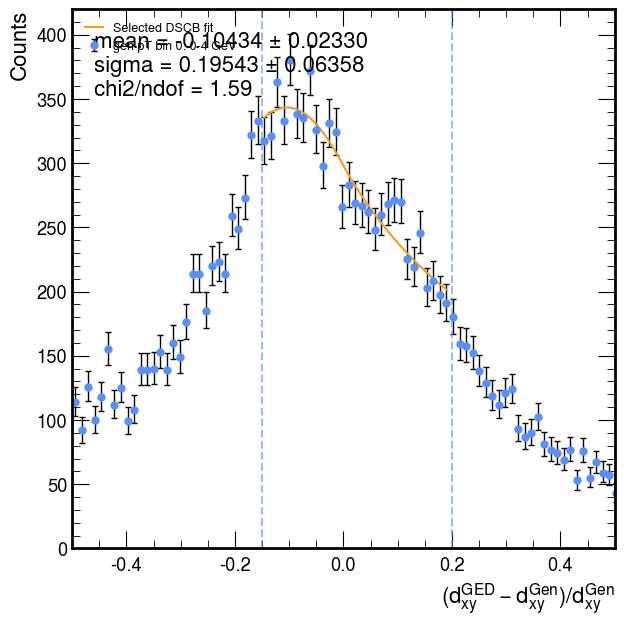

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


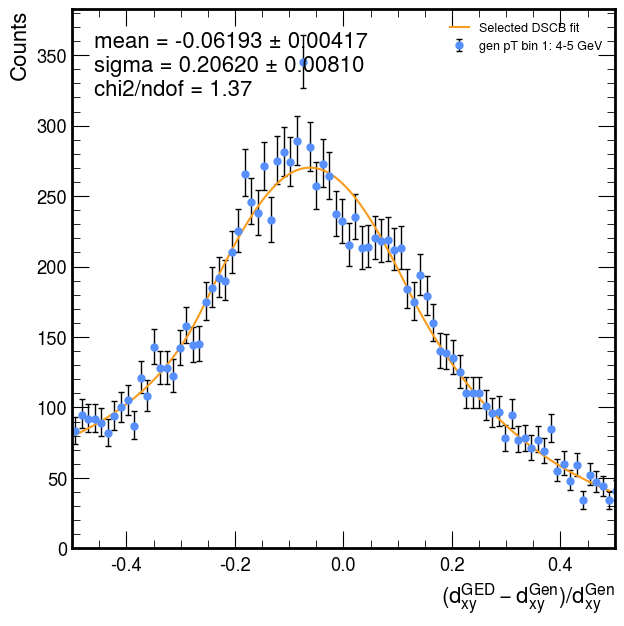

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


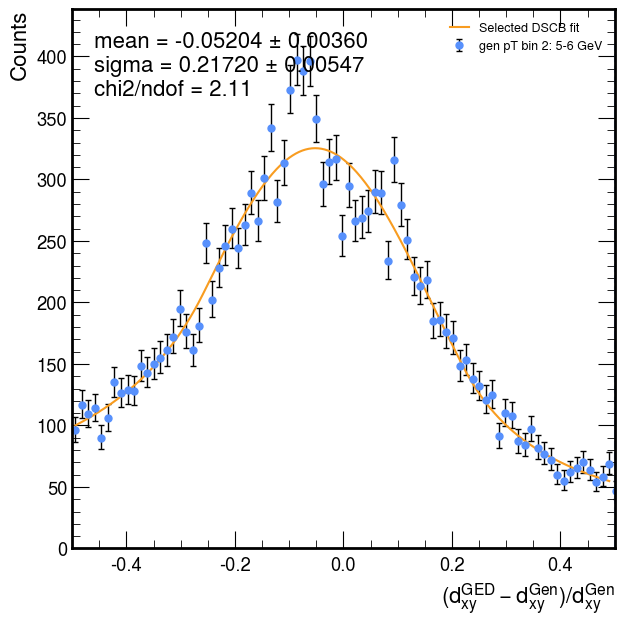

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


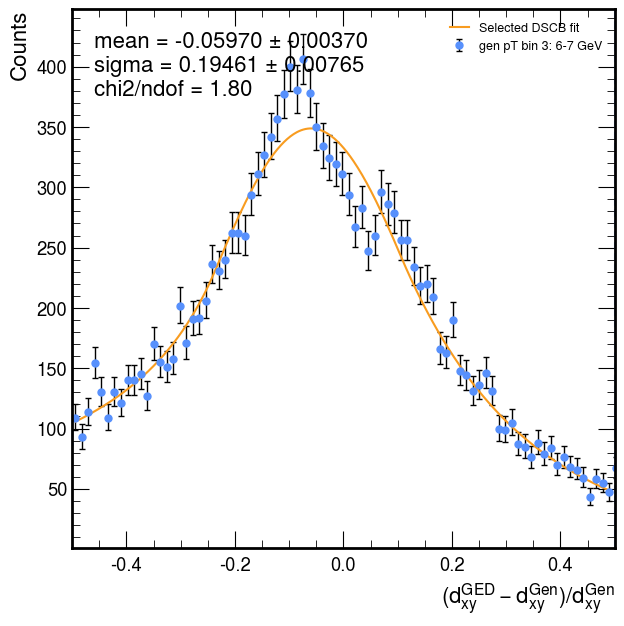

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


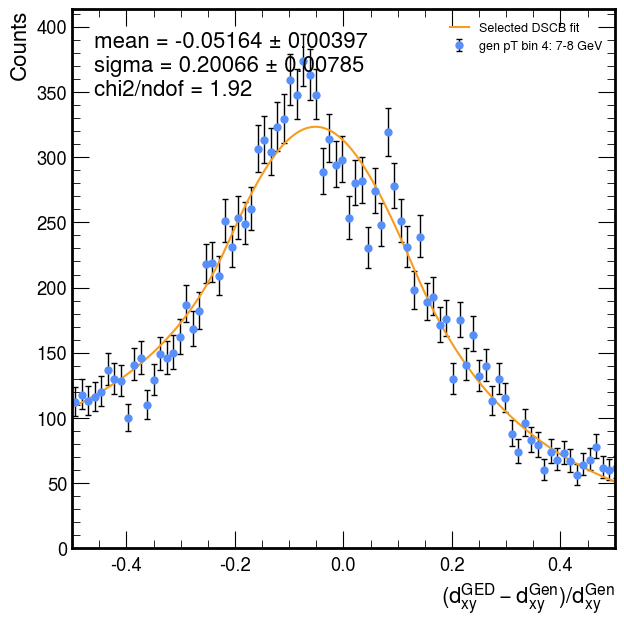

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


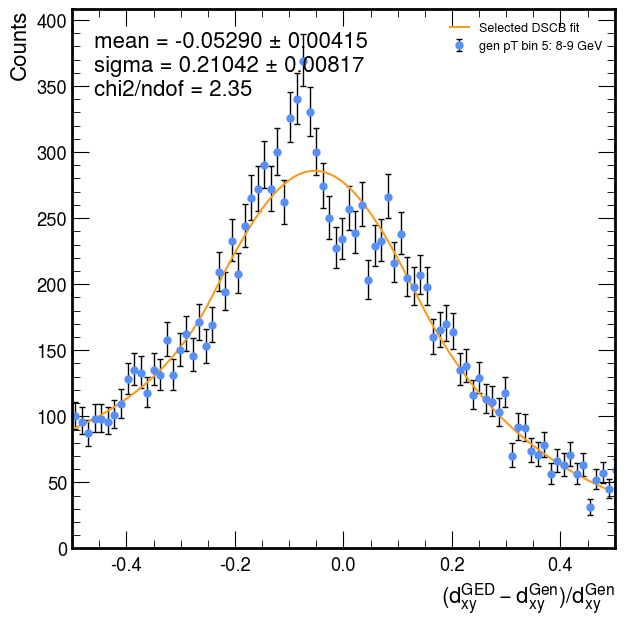

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


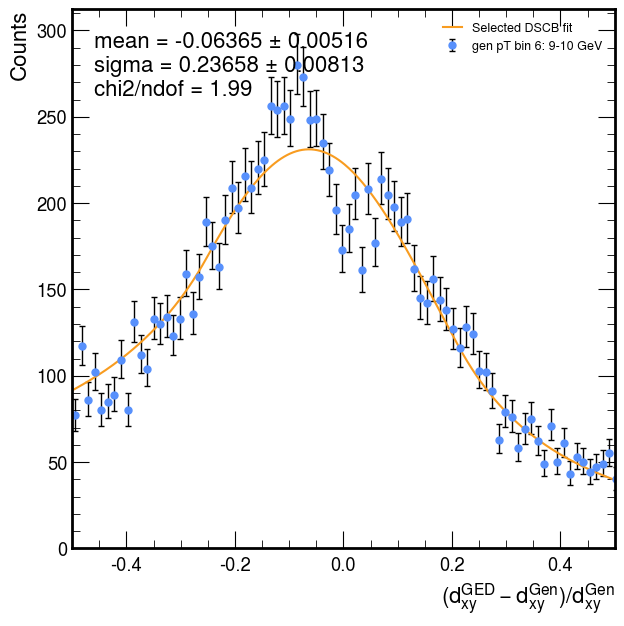

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


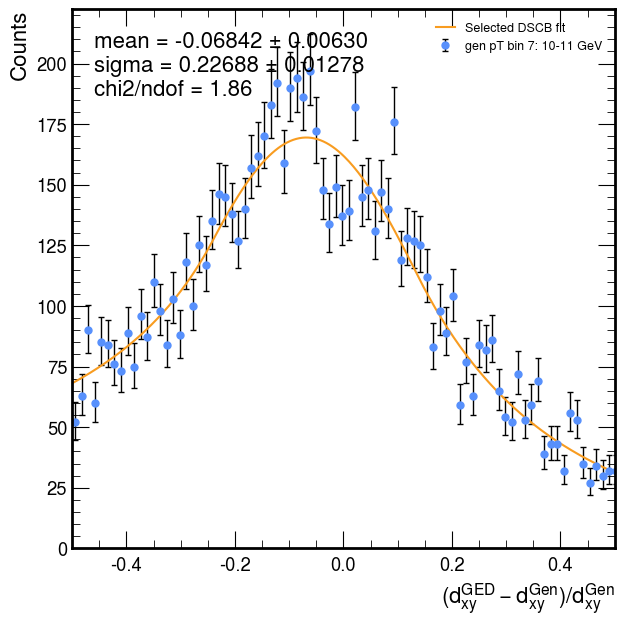

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


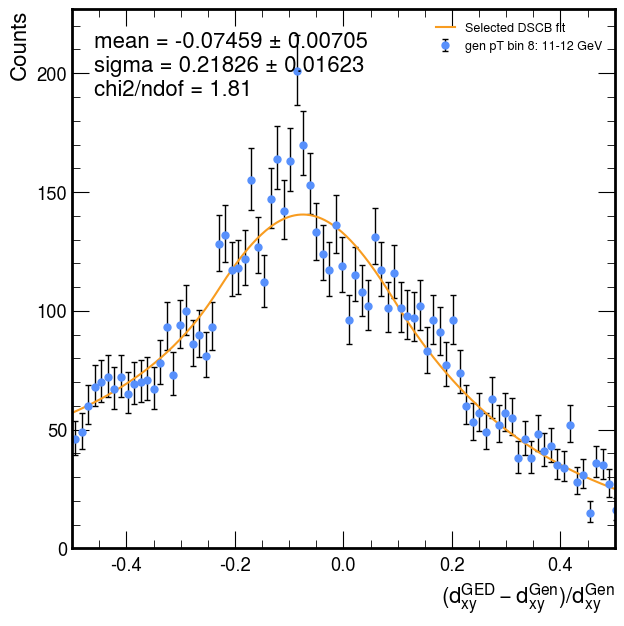

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


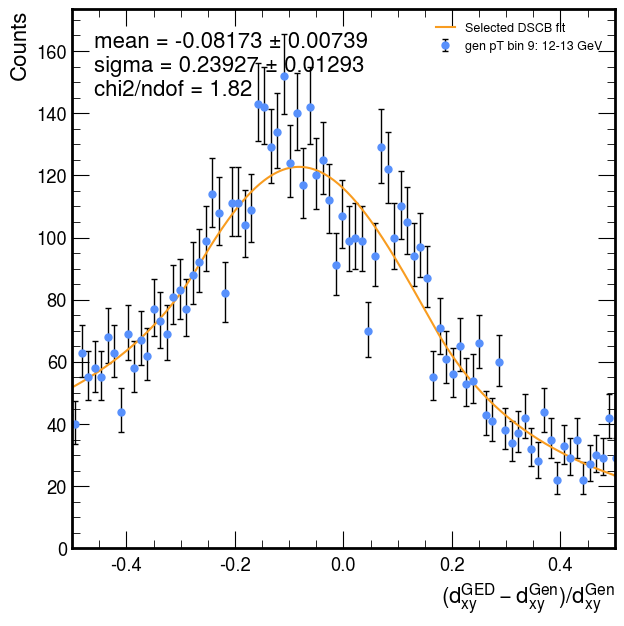

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


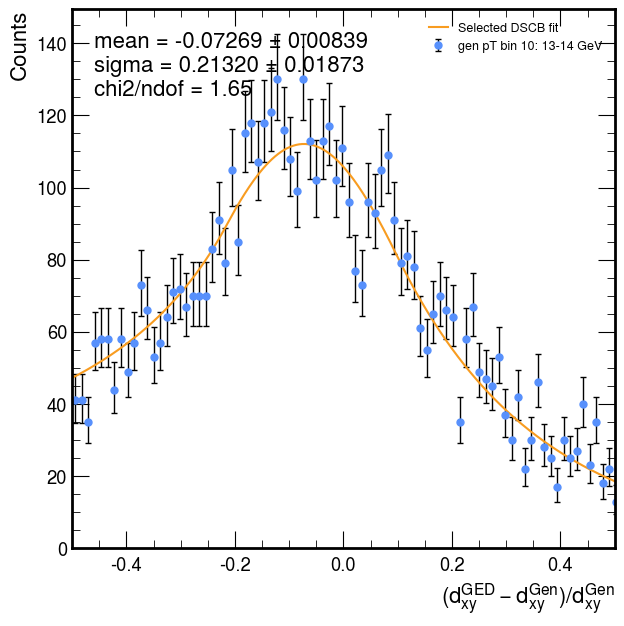

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


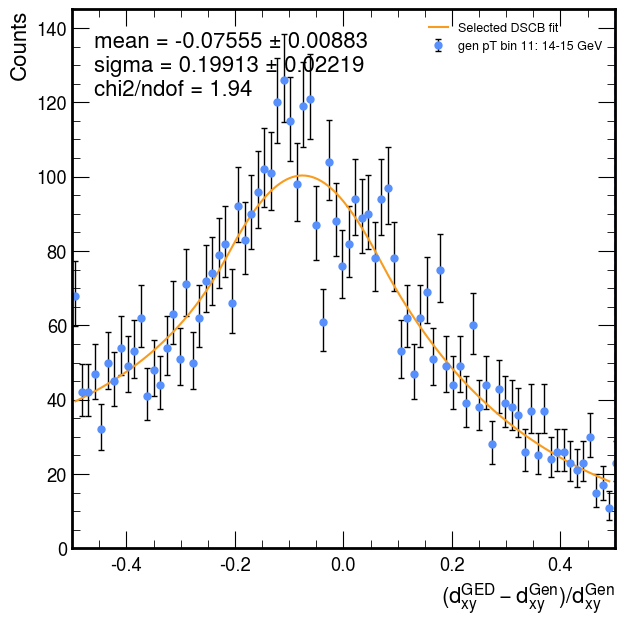

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


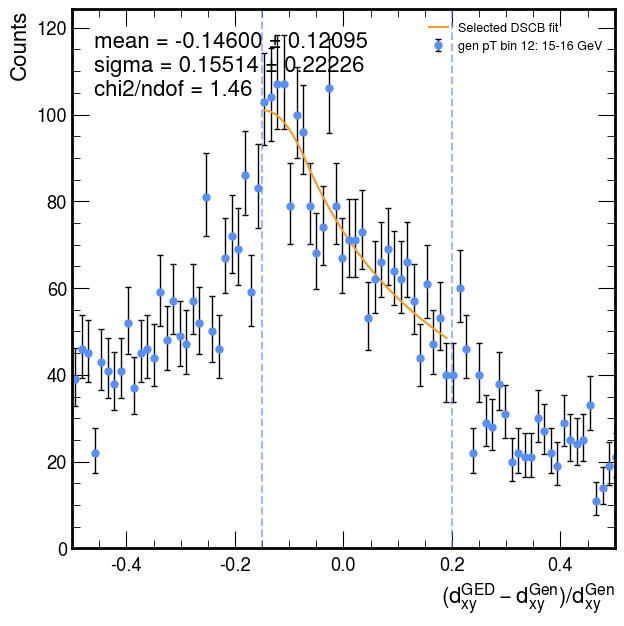

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


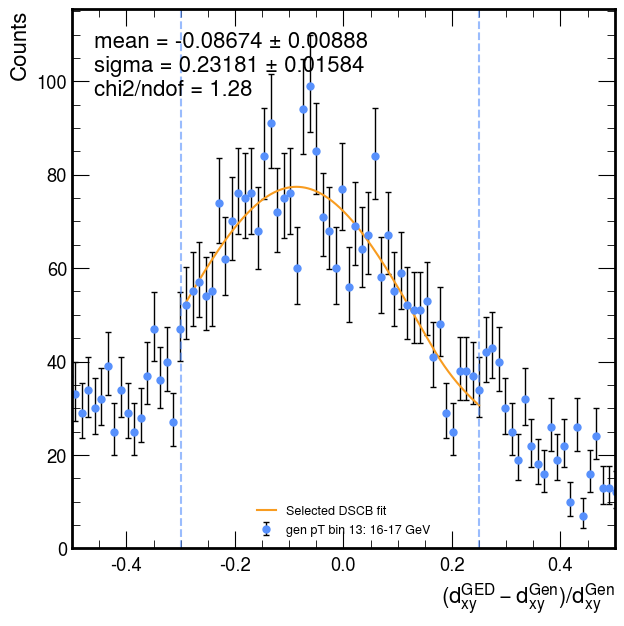

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


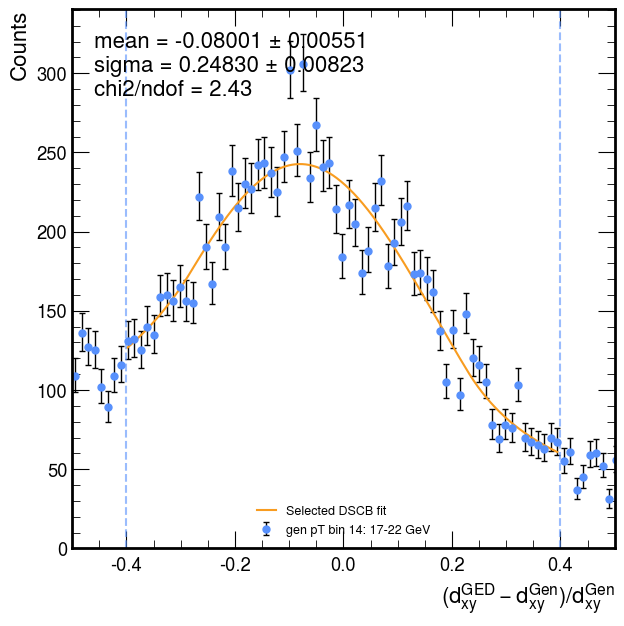

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


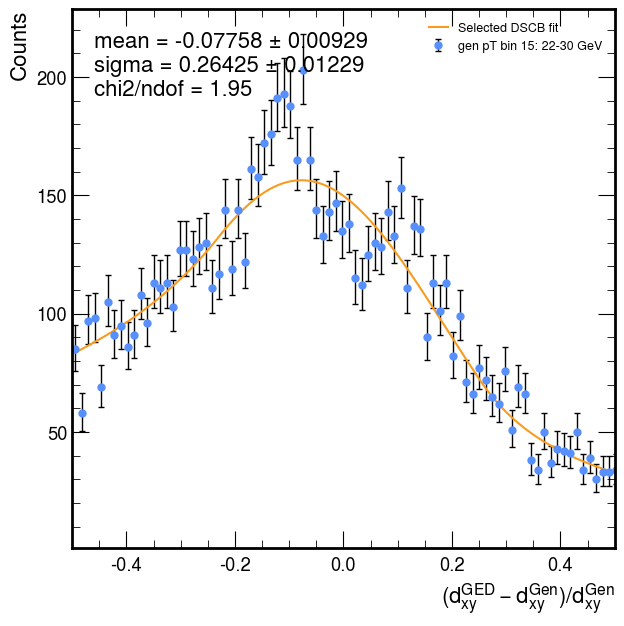

sigma_next= [0.19542940438655165, 0.20620276298761775, 0.2172046479198676, 0.19460847497507386, 0.20065957233898482, 0.21041506049485137, 0.23658103885255694, 0.22687812879366098, 0.21826244571205325, 0.23927411627484446, 0.2132032368532743, 0.1991263510889273, 0.1551390770529207, 0.23180754030890982, 0.24829720392487345, 0.2642459085666145]
sigma_unc_next= [0.0635833158743669, 0.00810142095925919, 0.005470553854573562, 0.00764965672811426, 0.007848985373262, 0.008172911857563324, 0.008132534765320058, 0.01278362709510478, 0.016226118153633673, 0.012932075488821464, 0.018733310324500665, 0.022191890362645655, 0.2222578180449136, 0.015843593627565628, 0.008225831835346897, 0.012286086501786708]


In [13]:
# ============================================================
# Final fit plots -- one plot per generated-pT bin
# ============================================================
sigma_next=[]
sigma_unc_next=[]
for idx in range(n_pt_bins):
    result = final_fit_results[idx]
    baseline = baseline_results[idx]
    sigma_change = abs(result['fit_sigma']-baseline['fit_sigma'])/baseline['fit_sigma']

    plt.figure(figsize=(7, 7))
    mplhep.histplot(
        h_fit[idx, :],
        histtype='errorbar', yerr=True, fmt='o', capsize=2,
        ecolor='black',
        label=f'gen pT bin {idx}: {result["genpt_bin"][0]:g}-{result["genpt_bin"][1]:g} GeV'
    )

    x_curve = np.linspace(result['xfit'].min(), result['xfit'].max(), 500)
    plt.plot(x_curve, double_cb(x_curve, *result['popt']), label='Selected DSCB fit')

    plt.axvline(result['fit_range'][0], linestyle='--', alpha=0.6)
    plt.axvline(result['fit_range'][1], linestyle='--', alpha=0.6)

    plt.xlim(plot_min, plot_max)
    plt.xlabel(r'$(d_{xy}^{GED}-d_{xy}^{Gen})/d_{xy}^{Gen}$')
    plt.ylabel('Counts')
    plt.text(
        0.04, 0.96,
        (
         f'mean = {result["fit_mean"]:.5f} ± {result["fit_mean_unc"]:.5f}\n'
         f'sigma = {result["fit_sigma"]:.5f} ± {result["fit_sigma_unc"]:.5f}\n'
         
         f'chi2/ndof = {result["chi2/ndof"]:.2f}'),
        transform=plt.gca().transAxes,
        va='top'
    )
    plt.legend(fontsize=9)
    plt.show()
    sigma_next.append(result["fit_sigma"])
    sigma_unc_next.append(result["fit_sigma_unc"])
print ("sigma_next=", sigma_next)
print ("sigma_unc_next=", sigma_unc_next)


In [14]:
# Optional diagnostic: inspect the fitted DSCB tail parameters.
# Values repeatedly sitting on a bound are a warning that the tails are not well constrained.
tail_rows = []
for idx, result in final_fit_results.items():
    tail_rows.append({
        'pT bin': result['genpt_bin'],
        'mu': result['fit_mean'],
        'sigma': result['fit_sigma'],
        'nL': result['nL'],
        'alphaL': result['alphaL'],
        'nR': result['nR'],
        'alphaR': result['alphaR'],
        'chi2/ndof': result['chi2/ndof'],
    })

display(pd.DataFrame(tail_rows))


,pT bin,mu,sigma,nL,alphaL,nR,alphaR,chi2/ndof
0,"(0.0, 4.0)",-0.104341,0.195429,18.988773,0.725768,1.010000,0.500000,1.591404
1,"(4.0, 5.0)",-0.061926,0.206203,1.010000,0.968316,20.000000,0.867864,1.366772
2,"(5.0, 6.0)",-0.052040,0.217205,1.173987,0.938756,1.155033,1.262311,2.111141
3,"(6.0, 7.0)",-0.059696,0.194608,1.010000,0.898323,20.000000,0.847755,1.798457
4,"(7.0, 8.0)",-0.051645,0.200660,1.010000,0.808252,4.216703,0.921838,1.915741
5,"(8.0, 9.0)",-0.052900,0.210415,1.010000,0.904880,20.000000,0.904108,2.351739
6,"(9.0, 10.0)",-0.063649,0.236581,1.010000,0.797325,2.055410,1.168853,1.987437
7,"(10.0, 11.0)",-0.068415,0.226878,1.010000,0.755868,5.515339,0.900010,1.856539
8,"(11.0, 12.0)",-0.074593,0.218262,1.010000,0.726882,20.000000,0.794249,1.810408
9,"(12.0, 13.0)",-0.081728,0.239274,1.010000,0.774058,2.103789,1.048970,1.822130


## 6. Final pT-resolution summary

This is the same downstream quantity as in your original notebook: the fitted DSCB core `sigma` plotted against the generated-pT bins. The x-axis is correctly labeled as generated pT here.

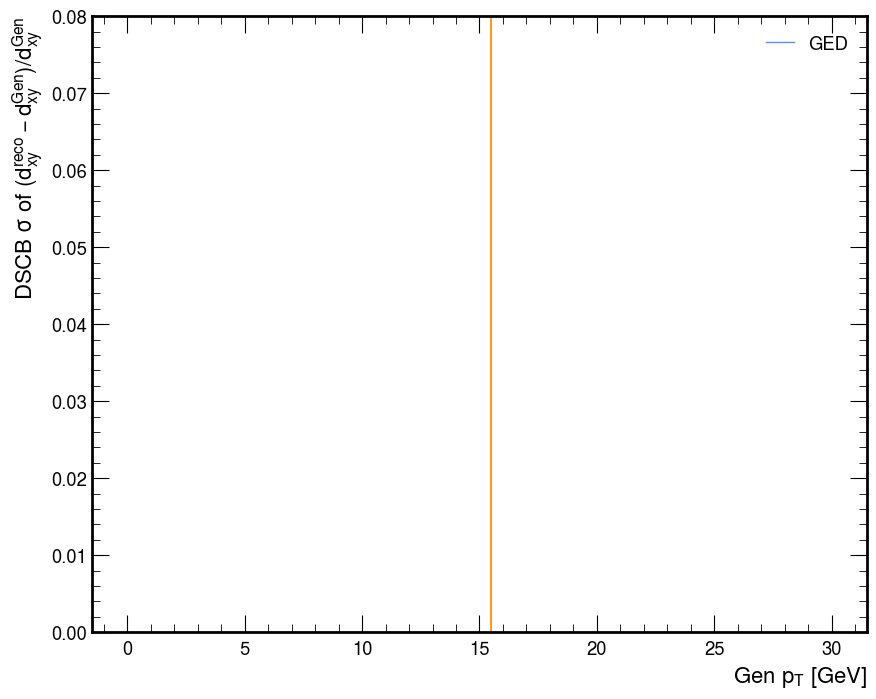

In [15]:
plot_data = []
genpt_edges = []

for item in fit_data:
    pt_low, pt_high = item['genptbin_range']
    pt_center = 0.5 * (pt_low + pt_high)

    if not genpt_edges:
        genpt_edges.append(pt_low)
    genpt_edges.append(pt_high)

    plot_data.append({
        'Genpt_center': pt_center,
        'DSCB sigmafit': item['fit_sigma'],
        'sigma_unc': item['fit_sigma_unc'],
    })

genpt = [p['Genpt_center'] for p in plot_data]
sigma = [p['DSCB sigmafit'] for p in plot_data]
sigma_unc = [p['sigma_unc'] for p in plot_data]

plt.figure(figsize=(10, 8))
plt.stairs(sigma, genpt_edges, baseline=None, label='GED')
plt.errorbar(genpt, sigma, yerr=sigma_unc, fmt='o', capsize=2)
plt.ylim(0,0.08)
plt.xlabel(r'Gen $p_T$ [GeV]')
plt.ylabel(r'DSCB $\sigma$ of $(d_{xy}^{reco}-d_{xy}^{Gen})/d_{xy}^{Gen}$')
plt.legend()
plt.show()


### What to inspect after running

The most important outputs are the **selection table** and the **baseline-vs-selected overlay plots**. A lower chi2/ndof is useful only when the central DSCB width remains stable and the selected interval still contains enough of the distribution to constrain the DSCB shape. The final comparison table makes that check explicit for every generated-pT bin.